# Bayesian Sharpe Ratio

Posterior simulation gives a distribution for each strategy Sharpe ratio instead of a single point estimate.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bayesian_utils import ensure_output_dir, simulate_strategy_returns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()
from bayesian_utils import bayesian_sharpe_samples, compare_bayesian_sharpe


In [2]:
returns = simulate_strategy_returns(periods=1_260, seed=303)
comparison = compare_bayesian_sharpe(returns, ['quality', 'momentum', 'defensive'])
comparison.to_csv(OUTPUT / 'bayesian_sharpe_comparison.csv', index=False)
comparison

,strategy,mean,lower_95,upper_95
0,defensive,0.5155,-0.3604,1.3815
1,quality,0.5099,-0.3635,1.3790
2,momentum,-0.3985,-1.2914,0.4775


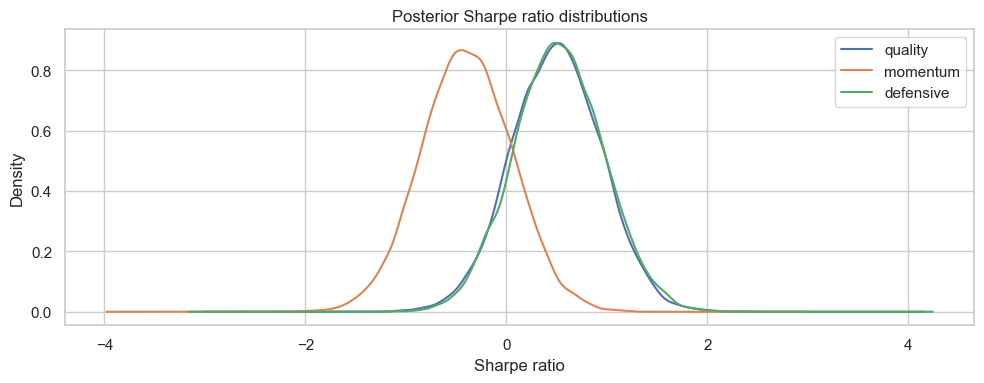

In [3]:
draws = pd.DataFrame({
    column: bayesian_sharpe_samples(returns[column], seed=410 + i)
    for i, column in enumerate(['quality', 'momentum', 'defensive'])
})
fig, ax = plt.subplots(figsize=(10, 4))
draws.plot(kind='density', ax=ax)
ax.set(title='Posterior Sharpe ratio distributions', xlabel='Sharpe ratio')
plt.tight_layout()